<a href="https://colab.research.google.com/github/winnieahedo/everpeak-analysis/blob/main/S7_FinalProject_ConnectaTel_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [ ]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print((users.isna().sum()) / (users.shape[0]))

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print((usage.isna().sum()) / (usage.shape[0]))

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**:
Se realiza exploración de cada Dataset para identificar número de registros, tipo de columnas y valores nulos que podrían afectar en el proceso de análisis.

💡 **Nota:**
- _plans_ no tiene valores nulos → no requiere ninguna acción.
- _users_ cuenta con 2 columnas que contienen valores nulos: City y Churn_Date.
- _usage_ muestra 3 columnas con valores nulos: Date, Duration y Length.

**Valores nulos**  
- City tiene el 11.72% de valores nulos. Se recomienda investigar la causa antes de decidir si imputarlos o mantenerlos como nulos, ya que una imputación incorrecta podría alterar el análisis.
- Churn_Date con el 88.35% puede indicar que un alto número de usuarios **no** ha abandonado el servicio, se recomienda conservar la columna, no imputarlos y mantenerlos como nulos dado que tienen sentido.
- Date apenas con el 0.125% de nulos, podrían ser imputados dependiendo la causa o eliminarlos en caso de no poder determinar la fecha.
- Para Duration y Length se necesita más información sobre la relación que tienen con Type para sabere si los nulos son normales o requieren algún tratamiento.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
users[["user_id","age"]].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene valores que se encuentran entre 10,000 y 13,999 y corresponden a identificadores de clientes, por lo que no resulta relevante realizar un análisis estadístico sobre esta variable.
- La columna `age` Se identifica un valor atípico de -999, que no corresponde a una edad válida y podría representar un valor faltante o desconocido.

In [ ]:
usage[["id","user_id","duration","length"]].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` no se observa un valor evidentemente anómalo en el rango.
- Las columnas `duration y length` presentan una diferencia considerable entre sus valores centrales y el máximo observado, lo que podría indicar valores atípicos.

In [ ]:
# explorar columna categórica de users
users[["city","plan"]].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` contiene 7 ciudades únicas. La ciudad más frecuente es Bogotá, con 808 registros. Además, hay 469 valores faltantes porque count es 3531 de 4000.
- La columna `plan` contiene 2 categorías únicas. El plan más frecuente es Basico, con 2595 registros.

In [ ]:
# explorar columna categórica de usage
usage["type"].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` contiene 2 categorías únicas. La categoría más frecuente es text, con 22,092 registros.

✍️ **Comentario**: Se realiza la revisión de las columnas numéricas y categóricas de los datasets Users y Usage para identificar posibles valores inválidos o sentinels que puedan afectar el análisis.

**Valores inválidos o sentinels**  
- Se identifica el valor atípico mínimo de -999 en la columna age del dataset Users, el cual corresponde a un valor inválido.
- Las columnas duration y length del dataset Usage presentan valores atípicos que pueden afectar el cálculo de los promedios.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce",utc=True)

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors="coerce",utc=True)

In [ ]:
# Revisar los años presentes en `reg_date` de users
users["reg_date"].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date`, se observa que existe un registro con el año 2026, lo cual debe revisarse para decidir qué hacer con ese valor fuera de rango del dataset.

In [ ]:
# Revisar los años presentes en `date` de usage
usage["date"].dt.year.unique()

array([2024.,   nan])

En `date`, Hay registros correctos del año 2024, sin embargo, hay registros faltantes/inválidos que no pudieron convertirse a fecha.

✍️ **Comentario**: Se realiza la revisión de las columnas que contienen fechas para identificar anomalías y/o fechas posteriores a 2024. Se utiliza pd.to_datetime para convertir las columnas a formato de fecha y .dt.year para extraer únicamente el año de los registros.

**Fechas fuera de rango**  
- En el dataset Users se identifican registros correspondientes al año 2026. Se recomienda realizar una inspección para cuantificar estos registros y determinar la acción correspondiente.
- En el dataset Usage, la columna date contiene valores que quedaron como faltantes o inválidos después de la conversión a formato de fecha.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users["age"].median()
users['age'] = users["age"].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios
users["city"].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year > 2024 , "reg_date"] = pd.NA

# Verificar cambios
users["reg_date"].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:

# Verificación MAR en usage (Missing At Random) para duration
usage["duration"].isna().groupby(usage["type"]).mean()


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage["length"].isna().groupby(usage["type"]).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Todos los registros de tipo text tienen duration nulo, mientras que los registros de tipo call no presentan valores faltantes. Por lo tanto, los nulos se consideran MAR respecto a type y se mantienen sin imputación.
Una llamada no tiene un length asociado al número de caracteres de un texto, por lo que esa variable no aplica y queda nula.
Mientras que los registros de tipo text sí tienen un contenido textual, por lo que length está presente en prácticamente todos los registros.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({"is_text":"sum","is_call":"sum","duration":"sum"}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:


# Renombrar columnas
usage_agg.rename(columns={"is_text":"cant_mensajes","is_call":"cant_llamadas","duration":"cant_minutos_llamada"},inplace=True)

# observar resultado
usage_agg.head(3)



,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg,on=["user_id"],how="inner")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4,3,8.01


### 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[["user_id","age","cant_mensajes","cant_llamadas","cant_minutos_llamada"]].describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,48.124531,5.524381,4.478120,23.317054
std,1154.898108,17.692032,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.500000,33.000000,4.000000,3.000000,11.120000
50%,12000.000000,47.000000,5.000000,4.000000,19.780000
75%,12999.500000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True).mul(100).round(2)

Basico     64.87
Premium    35.13
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

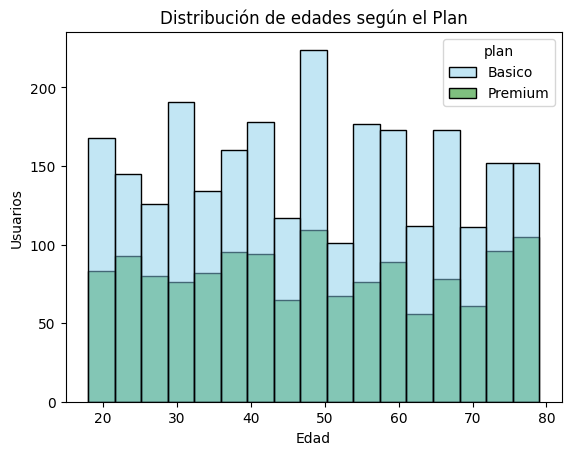

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"]
)
plt.title("Distribución de edades según el Plan")
plt.xlabel("Edad")
plt.ylabel("Usuarios")
plt.show()

💡Insights:
- La distribución de edades parece aproximadamente simétrica, ya que a partir de la concentración alrededor de los 47–48 años, hacia ambos lados se observa una disminución de las edades de manera bastante similar.

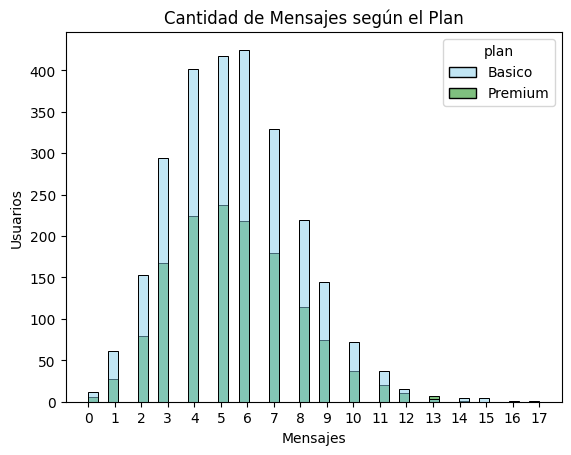

In [ ]:
# Histograma para visualizar la cant_mensajes

sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"]
)
plt.title("Cantidad de Mensajes según el Plan")
plt.xlabel("Mensajes")
plt.ylabel("Usuarios")
plt.xticks(range(0, 18))
plt.show()


💡Insights:
- La distribución de la cantidad de mensajes presenta un sesgo hacia la derecha, ya que la mayor concentración de usuarios se encuentra entre 4 y 6 mensajes, mientras que la frecuencia disminuye conforme aumenta el número de mensajes, extendiéndose la distribución hasta los 17 mensajes. Los usuarios del plan Premium presentan una mayor concentración en los valores más frecuentes de mensajes.

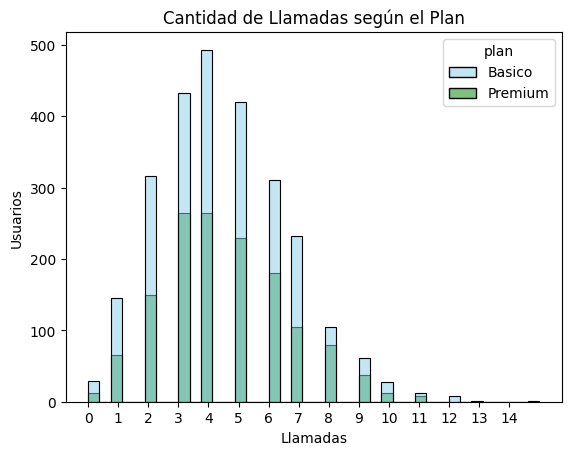

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"]
)
plt.title("Cantidad de Llamadas según el Plan")
plt.xlabel("Llamadas")
plt.ylabel("Usuarios")
plt.xticks(range(0, 15))
plt.show()

💡Insights:
- La distribución de la cantidad de llamadas presenta un sesgo hacia la derecha. La mayor concentración de usuarios se encuentra entre 3 y 5 llamadas, mientras que la frecuencia disminuye conforme aumenta el número de llamadas. Una proporción menor de usuarios realiza más de 8 llamadas. No se observa una diferencia claramente marcada entre los usuarios de los planes Básico y Premium.

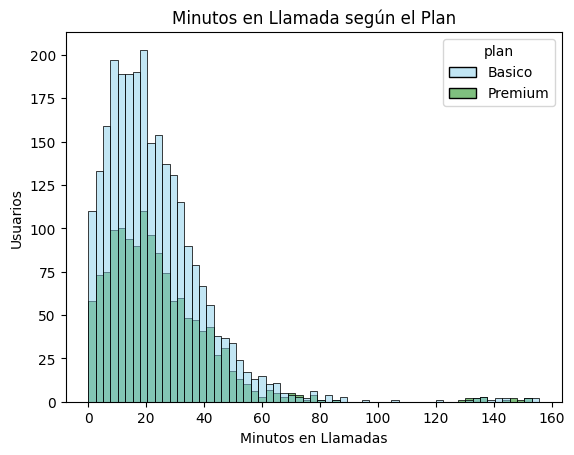

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"]
)
plt.title("Minutos en Llamada según el Plan")
plt.xlabel("Minutos en Llamadas")
plt.ylabel("Usuarios")
plt.show()

💡Insights:
- La distribución de los minutos de llamadas presenta un sesgo hacia la derecha, con una mayor concentración de usuarios entre 10 y 20 minutos. A partir de este rango, la frecuencia disminuye conforme aumenta el tiempo acumulado en llamadas. Los usuarios de los planes Básico y Premium presentan un comportamiento similar hasta aproximadamente los 30 minutos, mientras que en valores superiores se observa una mayor presencia de usuarios del plan Premium.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

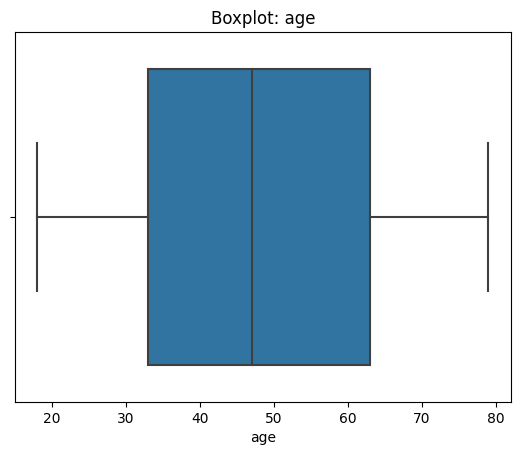

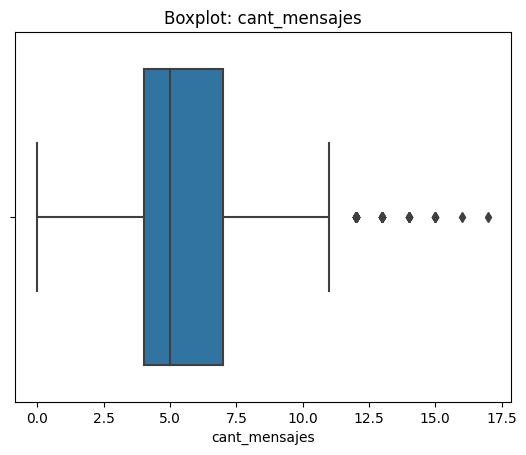

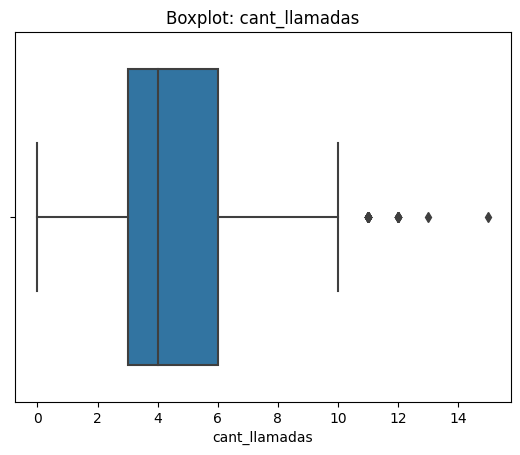

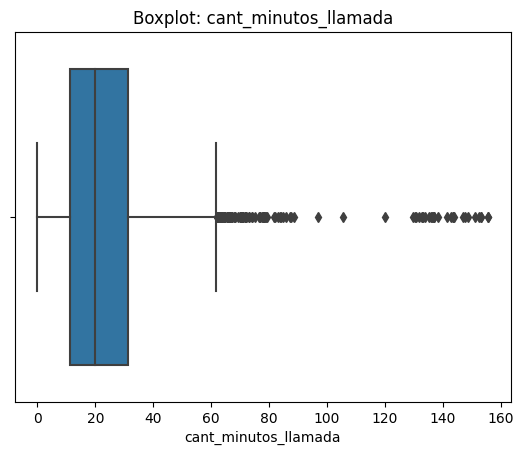

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_numericas:
    sns.boxplot(data=user_profile,x=col)
    plt.title(f"Boxplot: {col}")
    plt.show()


💡Insights:
- Age: No presenta outliers.
- cant_mensajes: ~6 outliers a partir de 12.
- cant_llamadas: ~4 outliers a partir de ~11.
- cant_minutos_llamada: muchos outliers a partir de ~60.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    print(col,upper)


cant_mensajes 11.5
cant_llamadas 10.5
cant_minutos_llamada 61.8575


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: presenta valores atípicos por encima de 11.5, con un máximo de 17 mensajes. Estos valores se consideran posibles comportamientos reales de los usuarios y no se identifican como errores de captura, por lo que se mantienen en el análisis.
- cant_llamadas: presenta valores atípicos por encima de 10.5, alcanzando un máximo de 15 llamadas. Debido a que estos valores representan un comportamiento posible de los usuarios y no muestran indicios de errores de captura, se mantienen para el análisis.
- cant_minutos_llamada: presenta numerosos valores atípicos por encima de 61.8575 minutos, con un máximo de 155.69 minutos. Aunque son valores extremos respecto a la distribución, representan un nivel de uso posible y no se identifican como errores de datos, por lo que se mantienen en el análisis.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def uso(row):
    mensajes = row["cant_mensajes"]
    llamadas = row["cant_llamadas"]

    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"

    elif llamadas < 10 and mensajes < 10:
        return "Uso medio"

    else:
        return "Alto uso"

user_profile["grupo_uso"] = user_profile.apply(uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def edad(row):
    age = row["age"]

    if age < 30:
        return "Joven"

    elif age < 60:
        return "Adulto"

    else:
        return "Adulto Mayor"

user_profile["grupo_edad"] = user_profile.apply(edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

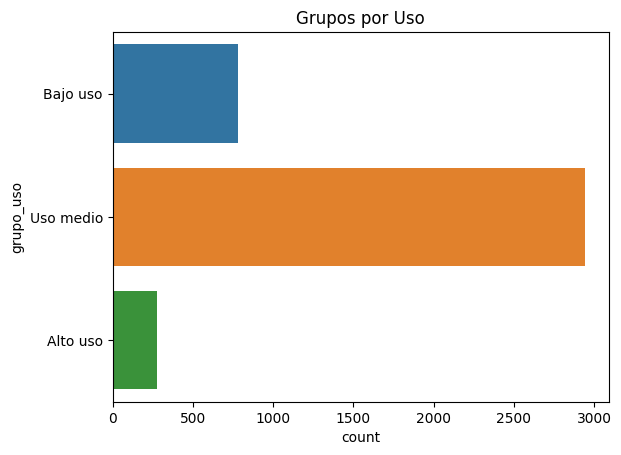

In [ ]:

# Visualización de los segmentos por uso
sns.countplot(data = user_profile, y="grupo_uso", order=["Bajo uso", "Uso medio", "Alto uso"])
plt.title("Grupos por Uso")
plt.show()

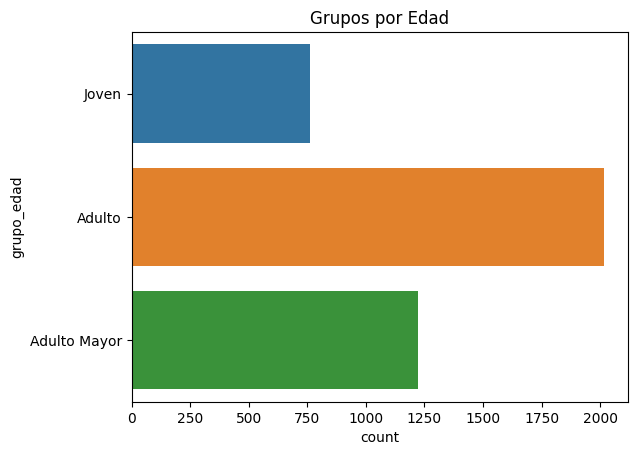

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data = user_profile, y="grupo_edad", order=["Joven","Adulto","Adulto Mayor"])
plt.title("Grupos por Edad")
plt.show()


---


## 🧩Paso 7: Insight Ejecutivo para Stakeholders

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
 Se detectaron valores nulos en 2 dataframes.- Users cuenta con 11.72% de valores nulos en City y 88.35% en Churn_date; para City se recomienda investigar la causa para decidir impputarlos o dejarlos nulos, mientras que para Churn_date el % puede ser normal, ya que represetaría a los usuarios que no han abandonado el servicio.
En el dataframe Usage, apenas el 0.125% de nulos en Date, podrían ser imputados o eliminados en caso de no poder determinar la fecha y para Duration y Length, se encontró que el porcentaje de nulos, corresponde correctamente a la relación que se tiene con la columna Type, lo cual significa un porcentaje normal.

 En la columna Age del dataframe Users, se identificó un valor sentinel de -999, en cuál fue reemplazado con la mediana de la misma columna.
Para la columna City, el sentinel "?" se reemplazó por valor nulo.
En las fechas de registro, se detectaron fechas del 2026, que no corresponden al límite de fecha del estudio hasta el 2024, el cuál fue reemplazado con nulo para no alterar el análisis.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
 Se identificaron 3 grupos de uso, de acuerdo con la cantidad de llamadas y mensajes obtenidos, esto representó un notable uso medio entre los usuarios, destacando un sesgo hacia la derecha, en donde además, se demuestra que hay poca diferencia entre los usuarios básicos y preminum.
El rango de edad con mayor uso se destaca entre 47 y 50 años de usuarios con el plan básico, manteniendo un uso medio destacable.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
 El grupo de Alto uso mostró ser un número bajo de usuarios, sin embargo, esto podría representar una oportunidad para la empresa, ya que la extensión de las llamadas y mensajes podría ser un indicador de que a ese grupo de usuarios puede llamarles la atención un plan más adecuado para ellos.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
 Los outliers identificados se muestran hacia un mayor número de mensajes, llamadas y la cantidad de minutos en ellas; esto puede implicar una necesidad de adaptación de planes para este segmento de usuarios y considerarlos dentro del análisis, para reforzar campañas.
Aunque estadísticamente son outliers, son comportamientos posibles de clientes reales, así que decidimos conservarlos.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
 Se recomienda mantener una oferta enfocada en los usuarios de uso medio, ya que representan el segmento predominante. Al mismo tiempo, sería conveniente evaluar la creación o adaptación de un plan dirigido a usuarios de alto consumo de llamadas y mensajes, ofreciendo beneficios acordes con sus necesidades para favorecer su retención e incrementar los ingresos.

También se recomienda utilizar la segmentación por edad y nivel de uso para desarrollar campañas más personalizadas. Los usuarios que presentan patrones de consumo elevados, incluidos los identificados como outliers, podrían recibir ofertas específicas en lugar de ser excluidos del análisis, ya que su comportamiento puede representar una oportunidad comercial.


✍️ **Escribe aquí tu análisis ejecutivo:**




### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valores nulos
- Valores inválidos
- Sentinels
- Años fuera de rango
- Columnas de tipo fecha sin formato

🔍 **Segmentos por Edad**
 - 'Joven' cuando age < 30
 - 'Adulto' cuando age < 60
 - 'Adulto Mayor' para el resto de casos

📊 **Segmentos por Nivel de Uso**
 - 'Bajo uso' cuando llamadas < 5 y mensajes < 5
 - 'Uso medio' cuando llamadas < 10 y mensajes < 10
 - 'Alto uso' para el resto de casos

➡️ Esto sugiere que ...

💡 **Recomendaciones**
 - Diseñar ofertas más adecuadas para usuarios de alto consumo.
 - Crear campañas segmentadas según edad + nivel de uso.
 - Utilizar esos patrones para retener clientes y detectar oportunidades de ingresos